In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import logging
from sentence_transformers import SentenceTransformer, LoggingHandler
from datasets import Dataset, load_from_disk

import pandas as pd
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Set the log level to INFO to get more information
logging.basicConfig(format="%(asctime)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S", level=logging.INFO, handlers=[LoggingHandler()])

In [3]:
# Load pre-trained Sentence-Transformer
# feature_model = SentenceTransformer("distilled/model-distillation-2024-09-30_17-50-39 (~9.1M 6L) [0, 5, 7, 9, 10, 11]/")
feature_model = SentenceTransformer("sentence-transformers/stsb-roberta-base-v2")

# Use the teacher model to get the gold embeddings
def map_embeddings(batch):
    return {
        "question1_embeddings": feature_model.encode(batch["question1"], show_progress_bar=False).tolist(),
        "question2_embeddings": feature_model.encode(batch["question2"], show_progress_bar=False).tolist()
    }

2025-08-28 10:33:44 - Use pytorch device_name: cuda:0
2025-08-28 10:33:44 - Load pretrained SentenceTransformer: sentence-transformers/stsb-roberta-base-v2


In [4]:
# class SNNHybridClassifier(nn.Module):
#     def __init__(self):
#         super(SNNHybridClassifier, self).__init__()
        
#         # Fully connected layers
#         self.fc1 = nn.Linear(768 + 768 + 1, 128)  # Adjust size based on pooling, add 1 for cosine similarity
#         self.fc2 = nn.Linear(128, 64)
#         self.dropout = nn.Dropout(p=0.3)
#         self.output_layer = nn.Linear(64, 2)

#     def forward(self, embedding1, embedding2):
#         # Compute cosine similarity
#         similarity = F.cosine_similarity(embedding1, embedding2, dim=-1).unsqueeze(-1)
        
#         # Concatenate cosine similarity with flattened CNN output
#         x = torch.cat((embedding1, embedding2, similarity), dim=1)
        
#         # Pass through fully connected layers
#         x = F.tanh(self.fc1(x))
#         x = self.dropout(x)
#         x = F.tanh(self.fc2(x))
#         output = self.output_layer(x)
#         return F.softmax(output, dim=1)
    
#     def predict(self, embedding1, embedding2):
#         """
#         Predict the class label for the given inputs.

#         Args:
#             embedding1 (torch.Tensor): The first input embedding tensor with shape (batch_size, 768).
#             embedding2 (torch.Tensor): The second input embedding tensor with shape (batch_size, 768).

#         Returns:
#             torch.Tensor: Predicted class labels with shape (batch_size,).
#         """
#         # Ensure the model is in evaluation mode
#         self.eval()
        
#         # Disable gradient computation for inference
#         with torch.no_grad():
#             # Forward pass
#             probabilities = self.forward(embedding1, embedding2)
            
#             # Get predicted class labels (index of the max probability)
#             predictions = torch.argmax(probabilities, dim=1)
#         return predictions
    
#     def evaluate(self, dataloader, device):
#         """
#         Evaluate the model on a given dataloader and print classification metrics.

#         Args:
#             dataloader (DataLoader): The dataloader containing test data.
#             device (torch.device): The device (CPU/GPU) for inference.

#         Returns:
#             None
#         """
#         self.eval()  # Set the model to evaluation mode
        
#         all_labels = []
#         all_predictions = []
        
#         with torch.no_grad():
#             for batch in dataloader:
#                 embedding1 = batch["question1_embeddings"].to(device)
#                 embedding2 = batch["question2_embeddings"].to(device)
#                 labels = batch["is_duplicate"].to(device)

#                 predictions = self.predict(embedding1, embedding2)
#                 all_labels.extend(labels.cpu().numpy())
#                 all_predictions.extend(predictions.cpu().numpy())
        
#         # Generate classification report
#         print("Classification Report:")
#         print(classification_report(all_labels, all_predictions, digits=4))

#         # Generate confusion matrix
#         cm = confusion_matrix(all_labels, all_predictions)
#         print("\nConfusion Matrix:")
#         print(cm)
        
class SNNHybridClassifier(nn.Module):
    def __init__(self):
        super(SNNHybridClassifier, self).__init__()
        
        # 1D CNN layers
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=32, kernel_size=3, padding=1)  # Convolution
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  # Convolution
        self.pool = nn.MaxPool1d(kernel_size=2)  # Pooling
        self.flatten = nn.Flatten()  # Flatten for dense layers
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * (768 // 4) + 1, 128)  # Adjust size based on pooling, add 1 for cosine similarity
        self.fc2 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(p=0.3)
        self.output_layer = nn.Linear(64, 2)

    def forward(self, embedding1, embedding2):
        # Concatenate embeddings along a new dimension (batch_size, 2, 768)
        combined_features = torch.stack((embedding1, embedding2), dim=1)  # Shape: (batch_size, 2, 768)
        
        # Pass through CNN layers
        x = F.tanh(self.conv1(combined_features))  # Shape: (batch_size, 32, 768)
        x = self.pool(x)  # Shape: (batch_size, 32, 384)
        x = F.tanh(self.conv2(x))  # Shape: (batch_size, 64, 384)
        x = self.pool(x)  # Shape: (batch_size, 64, 192)
        
        # Flatten the CNN output
        x = self.flatten(x)  # Shape: (batch_size, 64 * 192)
        
        # Compute cosine similarity
        similarity = F.cosine_similarity(embedding1, embedding2, dim=-1).unsqueeze(-1)  # Shape: (batch_size, 1)
        
        # Concatenate cosine similarity with flattened CNN output
        x = torch.cat((x, similarity), dim=1)  # Shape: (batch_size, 64 * 192 + 1)
        
        # Pass through fully connected layers
        x = F.relu(self.fc1(x))  # Shape: (batch_size, 128)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))  # Shape: (batch_size, 64)
        output = self.output_layer(x)  # Shape: (batch_size, 2)
        return F.softmax(output, dim=1)
    
    def predict(self, embedding1, embedding2):
        """
        Predict the class label for the given inputs.

        Args:
            embedding1 (torch.Tensor): The first input embedding tensor with shape (batch_size, 768).
            embedding2 (torch.Tensor): The second input embedding tensor with shape (batch_size, 768).

        Returns:
            torch.Tensor: Predicted class labels with shape (batch_size,).
        """
        # Ensure the model is in evaluation mode
        self.eval()
        
        # Disable gradient computation for inference
        with torch.no_grad():
            # Forward pass
            probabilities = self.forward(embedding1, embedding2)
            
            # Get predicted class labels (index of the max probability)
            predictions = torch.argmax(probabilities, dim=1)
        return predictions
    
    def evaluate(self, dataloader, device):
        """
        Evaluate the model on a given dataloader and print classification metrics.

        Args:
            dataloader (DataLoader): The dataloader containing test data.
            device (torch.device): The device (CPU/GPU) for inference.

        Returns:
            None
        """
        self.eval()  # Set the model to evaluation mode
        
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for batch in dataloader:
                embedding1 = batch["question1_embeddings"].to(device)
                embedding2 = batch["question2_embeddings"].to(device)
                labels = batch["is_duplicate"].to(device)

                predictions = self.predict(embedding1, embedding2)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
        
        # Generate classification report
        print("Classification Report:")
        print(classification_report(all_labels, all_predictions, digits=4))

        # Generate confusion matrix
        cm = confusion_matrix(all_labels, all_predictions)
        print("\nConfusion Matrix:")
        print(cm)

In [5]:
# Load the dataset
dataset = pd.read_csv("datasets/questions.csv")
dataset = dataset.drop(columns=['id', "qid1", "qid2"])
dataset = dataset.dropna()

# Separate majority and minority classes
majority_class = dataset[dataset['is_duplicate'] == 0]
minority_class = dataset[dataset['is_duplicate'] == 1]

# Upsample minority class
minority_class_upsampled = resample(minority_class, replace=True, n_samples=len(majority_class), random_state=42)

# Combine the majority class with the upsampled minority class
upsampled_dataset = pd.concat([majority_class, minority_class_upsampled])

# Shuffle the dataset
upsampled_dataset = upsampled_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the class distribution
print(upsampled_dataset['is_duplicate'].value_counts())

is_duplicate
0    255042
1    255042
Name: count, dtype: int64


In [6]:
# Convert into HuggingFace Dataset Type
upsampled_dataset = Dataset.from_pandas(upsampled_dataset, preserve_index=False)

In [7]:
upsampled_dataset = upsampled_dataset.map(map_embeddings)
upsampled_dataset.set_format(type="torch", columns=["question1_embeddings", "question2_embeddings", "is_duplicate"])

Map:   0%|          | 0/510084 [00:00<?, ? examples/s]

In [8]:
upsampled_dataset.save_to_disk("datasets/quora_stsb-RoBERTa-base-v2")
# upsampled_dataset = load_from_disk("datasets/quora_stsb6L/")

Saving the dataset (0/13 shards):   0%|          | 0/510084 [00:00<?, ? examples/s]

In [9]:
upsampled_dataset

Dataset({
    features: ['question1', 'question2', 'is_duplicate', 'question1_embeddings', 'question2_embeddings'],
    num_rows: 510084
})

In [10]:
# Split into train and test sets
train_test_split = upsampled_dataset.train_test_split(test_size=0.2, seed=42)

# Access the splits
train_dataset = train_test_split["train"]
test_dataset = train_test_split["test"]

In [11]:
test_dataset

Dataset({
    features: ['question1', 'question2', 'is_duplicate', 'question1_embeddings', 'question2_embeddings'],
    num_rows: 102017
})

In [12]:
def train_model(model, train_dataloader, test_dataloader, criterion, optimizer, epochs, device):
    model.to(device)  # Move the model to the GPU/CPU

    # Initialize lists to store metrics for plotting
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        tqdm.write(f"Epoch {epoch + 1}/{epochs}")

        # Training Phase
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        # Customized tqdm for training
        train_loop = tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}", leave=False, bar_format="{l_bar}{bar:30}{r_bar}", dynamic_ncols=True)
        for batch in train_loop:
            embedding1 = torch.tensor(batch["question1_embeddings"], dtype=torch.float32).to(device)
            embedding2 = torch.tensor(batch["question2_embeddings"], dtype=torch.float32).to(device)
            labels = torch.tensor(batch["is_duplicate"], dtype=torch.long).to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(embedding1, embedding2)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Accumulate loss and accuracy
            train_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Update tqdm with loss and accuracy
            train_loop.set_postfix({
                "loss": f"{train_loss / (total // batch['is_duplicate'].size(0)):.4f}",
                "accuracy": f"{correct / total:.4f}"
            })

        # Calculate average training loss and accuracy
        avg_train_loss = train_loss / len(train_dataloader)
        train_accuracy = correct / total

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        tqdm.write(f"Training Loss: {avg_train_loss:.5f}, Training Accuracy: {train_accuracy:.5f}")

        # Evaluation Phase
        model.eval()
        test_loss = 0
        correct = 0
        total = 0

        # Customized tqdm for evaluation
        test_loop = tqdm(test_dataloader, desc=f"Evaluating Epoch {epoch + 1}", leave=False, bar_format="{l_bar}{bar:30}{r_bar}", dynamic_ncols=True)
        with torch.no_grad():
            for batch in test_loop:
                embedding1 = torch.tensor(batch["question1_embeddings"], dtype=torch.float32).to(device)
                embedding2 = torch.tensor(batch["question2_embeddings"], dtype=torch.float32).to(device)
                labels = torch.tensor(batch["is_duplicate"], dtype=torch.long).to(device)

                # Forward pass
                outputs = model(embedding1, embedding2)
                loss = criterion(outputs, labels)

                # Accumulate loss and accuracy
                test_loss += loss.item()
                _, predicted = torch.max(outputs, dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        # Calculate average test loss and accuracy
        avg_test_loss = test_loss / len(test_dataloader)
        test_accuracy = correct / total

        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

        tqdm.write(f"Test Loss: {avg_test_loss:.5f}, Test Accuracy: {test_accuracy:.5f}\n")

    # Save the model
    model_save_path = f"snn_classifier_hybrid_model.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

    # Plot the training and validation loss and accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
    plt.plot(range(1, epochs + 1), test_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Over Epochs")

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label="Training Accuracy")
    plt.plot(range(1, epochs + 1), test_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Over Epochs")

    plt.tight_layout()
    plt.show()

In [13]:
# Define hyperparameters
batch_size = 32
epochs = 30
learning_rate = 1e-4

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Using device: {device}")

# Create model, optimizer, and loss function
model = SNNHybridClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Notes
# Cek activation function selain relu dan cari metode untuk concat semuanya (jangan semua diconcat sekaligus, mungkin bisa pakai CNN)
# Tambah jumlah epoch
# Batch size kecilkan
# Learning Rate 1e-5 coba lagi

Using device: cuda


Epoch 1/30


Training Epoch 1:   0%|                              | 0/12753 [00:00<?, ?it/s]/tmp/ipykernel_151497/499420879.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding1 = torch.tensor(batch["question1_embeddings"], dtype=torch.float32).to(device)
/tmp/ipykernel_151497/499420879.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding2 = torch.tensor(batch["question2_embeddings"], dtype=torch.float32).to(device)
/tmp/ipykernel_151497/499420879.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["is_

Training Loss: 0.48715, Training Accuracy: 0.81756


Evaluating Epoch 1:   0%|                              | 0/3189 [00:00<?, ?it/s]/tmp/ipykernel_151497/499420879.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding1 = torch.tensor(batch["question1_embeddings"], dtype=torch.float32).to(device)
/tmp/ipykernel_151497/499420879.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding2 = torch.tensor(batch["question2_embeddings"], dtype=torch.float32).to(device)
/tmp/ipykernel_151497/499420879.py:68: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["is

Test Loss: 0.46372, Test Accuracy: 0.84307

Epoch 2/30


...

Test Loss: 0.40117, Test Accuracy: 0.91057

Epoch 29/30


Training Loss: 0.36002, Training Accuracy: 0.95251


Test Loss: 0.39939, Test Accuracy: 0.91232

Epoch 30/30


Training Loss: 0.35924, Training Accuracy: 0.95330


Test Loss: 0.40003, Test Accuracy: 0.91148

Model saved to snn_classifier_hybrid_model.pth


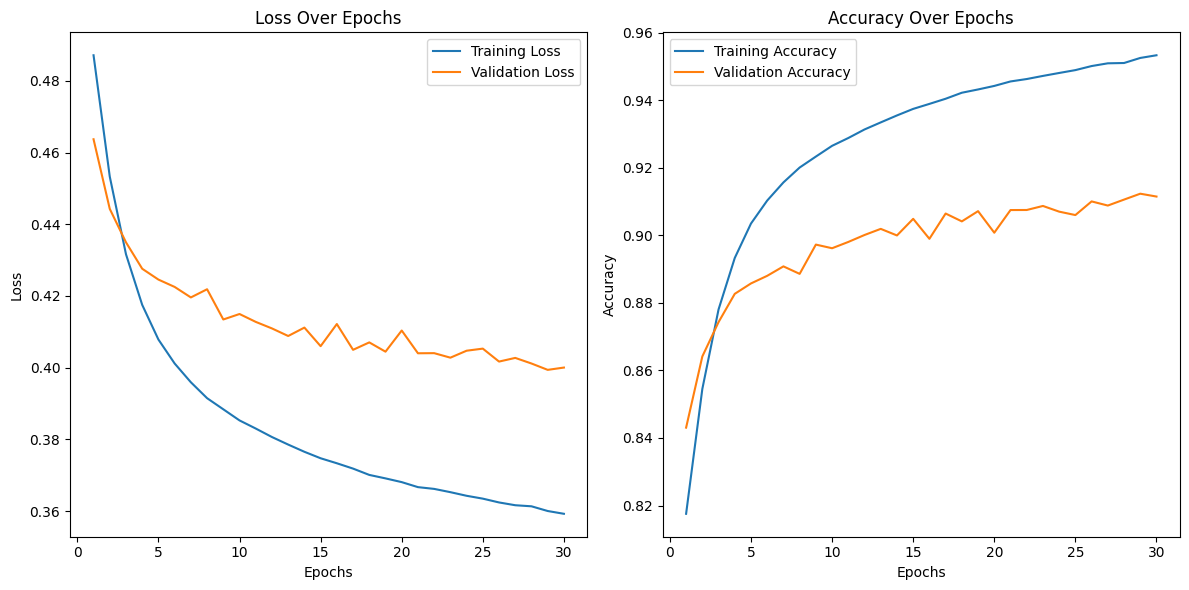

In [14]:
# Train the model
train_model(model, train_dataloader, test_dataloader, criterion, optimizer, epochs, device)

In [15]:
# # Initialize the model and load weights
# model = SNNHybridClassifier()
# model.load_state_dict(torch.load("snn_classifier_hybrid_model_base.pth"))
# model.to(device)

# Evaluate on test dataloader
model.evaluate(test_dataloader, device)

Classification Report:
              precision    recall  f1-score   support

           0     0.9321    0.8876    0.9093     51028
           1     0.8927    0.9353    0.9135     50989

    accuracy                         0.9115    102017
   macro avg     0.9124    0.9115    0.9114    102017
weighted avg     0.9124    0.9115    0.9114    102017


Confusion Matrix:
[[45295  5733]
 [ 3298 47691]]
